# Research Question 2
The second part of the original question has been reworded for clarity, and will be the focus of the first part of the investigation:

1. Can delays in seller handoff to the logistics carrier help us anticipate customer-facing delivery issues?
2. Which sellers consistently delay order handoffs to carriers, and what underlying patterns or behaviors contribute to this?  

## Part 0: Data Manipulation and preparation

In [1]:
# Load libraries and functions
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_venn as mv
import seaborn as sns
import statsmodels.api as sm

from imblearn.over_sampling import SMOTE
from scipy.stats import spearmanr, chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import precision_recall_curve, accuracy_score, recall_score, confusion_matrix, fbeta_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from statsmodels.stats import proportion as smsp

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings('ignore');

### Import and Manipulate Baseline

In [3]:
# Set directory path and import team's cleaned data set
os.chdir(r'C:\Users\opiwa\Documents\ASU\DAT_490\Data') # using raw literal to allow copy/paste from Windows paths
data = pd.read_csv('cleaned_dataset.csv', index_col = False, low_memory = False);

We will drop the following irrelevant columns since we have already generated an approximate distance between seller and customer in the 'distance_km' field:
 - customer_lat & customer_lng - the latitude and longitude coordinates of the customer
 - seller_lat & seller_lng - the latitude and longitude coordinates of the seller

We also drop 'is_first_time_buyer' as that has no logical reason to affect shippers' effectiveness at handing off deliveries.  Finally, we drop the "informational" product fields (length of name, length of description, number of photos) as well as the remaining review information, as neither of those groups are relevant to the question at hand.

In [5]:
data.drop(columns = ['customer_lat', 'customer_lng', 'is_first_time_buyer', 
                     'seller_lat', 'seller_lng', 'product_name_length', 'product_description_length', 
                     'product_photos_qty', 'review_id', 'review_score'], inplace=True);

In [7]:
data.columns

Index(['order_id', 'order_item_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_estimated_delivery_date', 'is_canceled',
       'customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_delivered_customer_date',
       'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'shipping_limit_date', 'order_delivered_carrier_date', 'handoff_delay',
       'distance_km', 'product_id', 'product_category_name_english', 'price',
       'freight_value', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'delivered_late',
       'delivery_delay'],
      dtype='object')

There are features left of questionable relevance, but we will keep them just in case they become important as the analysis proceeds.

To reduce the complexity of the set, we next extract the unique values within the order_id, customer_id, customer_unique_id, and seller_id columns so we can assign integer values to them in place of the 32-character hexadecimal values that are currently in place, since we have no need to trace those values back to the original databases.  We then join the resulting individual dataframes with the larger data set, dropping the original columns and leaving only the integer IDs.

In [9]:
# Create dataframes from extracted unique values of each ID column in the overall 'data' dataset
order = pd.DataFrame(data['order_id'].unique(), columns = ['order_id'])
cust = pd.DataFrame(data['customer_id'].unique(), columns = ['customer_id'])
cust_u = pd.DataFrame(data['customer_unique_id'].unique(), columns = ['customer_unique_id'])
sell = pd.DataFrame(data['seller_id'].unique(), columns = ['seller_id'])

# Add the integer index values to each set
order['order_id_int'] = range(1, len(order['order_id'])+1)
cust['customer_id_int'] = range(1, len(cust['customer_id'])+1)
cust_u['customer_unique_id_int'] = range(1, len(cust_u['customer_unique_id'])+1)
sell['seller_id_int'] = range(1, len(sell['seller_id'])+1)

# Merge each ID dataframe 'dictionary' to the greater dataset, then drop the original column, renaming the new column to the old name for consistency
data = data.merge(order, how = 'left', on = 'order_id')
data.drop(columns = 'order_id', inplace = True)
data = data.merge(cust, how = 'left', on = 'customer_id')
data.drop(columns = 'customer_id', inplace = True)
data = data.merge(cust_u, how = 'left', on = 'customer_unique_id')
data.drop(columns = 'customer_unique_id', inplace = True)
data = data.merge(sell, how = 'left', on = 'seller_id')
data.drop(columns = 'seller_id', inplace = True);

# Rename *_int columns to the original names
data.rename(columns = {'order_id_int':'order_id', 'customer_id_int':'customer_id', 'customer_unique_id_int':'customer_unique_id', 'seller_id_int':'seller_id'}, inplace=True)

# We also realize there were order in process when this set was published, so we will remove rows where there is no delivery date to the customer
data = data.dropna(subset = 'order_delivered_customer_date')

data.shape

(109306, 31)

## Part 1: Seller Handoff Delays and Correlation with Customer Delivery Delays

To recapitulate from the EDA (see the column name list after the original data loading and first drop operation above), features already exist that show the following:
1. 'delivered_late' - True/False indicator of if the 'order_delivered_customer_date' was later than the 'order_estimated_delivery_date'
2. 'delivery_delay' - Difference between 'order_delivered_customer_date' and 'order_estimated_delivery_date' in days, negative values being early deliveries and positive values being late deliveries.
3. 'handoff_delay' - Difference between 'order_delivered_carrier_date' and 'order_approved_at' in days

Since it's not clear if Olist has a policy that only allows sellers to be informed of a purchase needing shipment after payment has been approved or not, we will create a new field ('handoff_delay_alt') based on the difference between 'order_deliveredd_carrier_date' and 'order_purchase_timestamp' to see if that has less instances of negative values for the "delay", since it should be physically impossible to deliver the product for shipment without even knowing of the existence of an order.  The only negative values should be -1, and only then if the vagaries of time stamping across the four time zones spanning Brazil have an effect on the delivery/origin datetimes instead of the system adopting a universal time frame and enforcing it across the database.  We convert the various date/time fields to Pandas datetime datatype since the original import interpreted them as strings.

### Create Additional Necessary Features

In [11]:
# Convert date fields to the datetime datatype
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp']);
data['order_approved_at'] = pd.to_datetime(data['order_approved_at']);
data['order_estimated_delivery_date'] = pd.to_datetime(data['order_estimated_delivery_date']);
data['shipping_limit_date'] = pd.to_datetime(data['shipping_limit_date']);
data['order_delivered_carrier_date'] = pd.to_datetime(data['order_delivered_carrier_date']);
data['order_delivered_customer_date'] = pd.to_datetime(data['order_delivered_customer_date']);

data['handoff_delay_alt'] = (data['order_delivered_carrier_date'] - data['order_purchase_timestamp']).dt.days

# See descriptive statistics
print(data['handoff_delay_alt'].describe())

count    109305.000000
mean          3.255496
std           3.600074
min        -171.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         104.000000
Name: handoff_delay_alt, dtype: float64


Instead of plotting a histogram and comparing to EDA historgram, it's easier to compare number of negative delivery delay values in each column:

In [13]:
neg = len(data[data['handoff_delay']<-1])
neg_alt = len(data[data['handoff_delay_alt']<-1])
print(f"There are {neg} handoff delay values less than -1 in the original delay field and {neg_alt} in the alternative field");

There are 83052 handoff delay values less than -1 in the original delay field and 2 in the alternative field


Clearly, our original definition of handoff delay did not line up with the Oline business rules surrounding date/time recording in their database.  We will use the 'alt' value for all future comparisons.  If either of the values are -1, we will convert them to 0 and chalk it up to the time zone differences mentioned previously, otherwise we will drop those rows as errors we cannot resolve.

In [15]:
print(data['handoff_delay_alt'].nsmallest(2))

29025   -171.0
93479     -4.0
Name: handoff_delay_alt, dtype: float64


In [17]:
# Drop two negative rows since they both have absolute values greater than 1
data.drop(index = [29025,93479], inplace=True);

# Drop the original handoff_delay column as it is no longer necessary, rename the alternative to replace it
data.drop(columns = 'handoff_delay', inplace=True);
data.rename(columns = {'handoff_delay_alt':'handoff_delay'}, inplace=True);

In [19]:
data.shape

(109304, 31)

We now create a field ('promised_handoff_delay') that measures the difference between the 'order_delivered_carrier_date' field and the 'shipping_limit_date' field to determine if a handoff was early or late, much like the 'delivery_delay' field discussed above.

In [21]:
data['promised_handoff_delay'] = (data['order_delivered_carrier_date'] - data['shipping_limit_date']).dt.days

### Answering Part 1

We are finally in position to determine the answer to the first part of the research question.  First, we determine if there is a correlation between the overall handoff delivery delay ('handoff_delay') and the amount of time early/late the handoff is made to the carrier ('promised_handoff_delay') to help determine the effectiveness of the system's handoff delivery time estimate mechanism.  We will use the Spearman correlation method, since it has better performance when dealing with discrete, non-normal data.  We will not use Kendall's correlation (tau) method, since it concerns rank correlations between sets, and we do not have ranked individual values, but rather pairwise discrete values.

In [24]:
corr, p = spearmanr(data['handoff_delay'], data['promised_handoff_delay'], axis = 0, nan_policy='omit');
print(f"The Spearman correlation coefficient for time to handoff and days early/late for handoff compared to the promise date \nis {corr:.3f} with an associated p-value for the comparison of {p:.3f}.")

The Spearman correlation coefficient for time to handoff and days early/late for handoff compared to the promise date 
is 0.529 with an associated p-value for the comparison of 0.000.


Since the p-value is < 0.05, we reject the null hypothesis that the two sets do not have an ordinal correlation.  Based on the correlation coefficient, promised handoff delay should increase as the time it takes to make the handoff increases.  We can confirm that general relationship with a scatter plot.

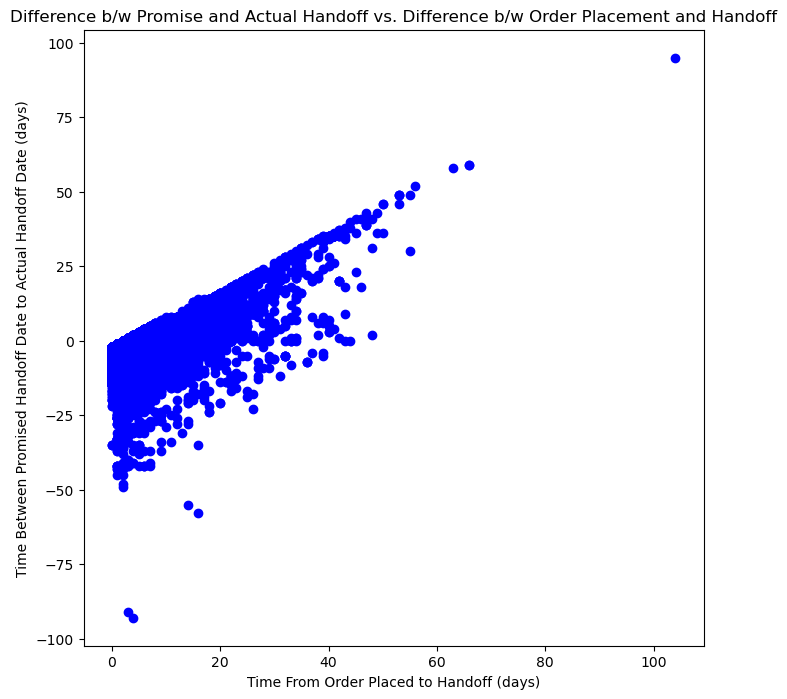

In [26]:
# Limit single extreme outlier by only plotting times 5 months early or less

plt.figure(figsize = (8,8))
plt.scatter(x = data[data['promised_handoff_delay']>-150]['handoff_delay'], 
            y = data[data['promised_handoff_delay']>-150]['promised_handoff_delay'], color = 'blue', marker = 'o')
plt.xlabel('Time From Order Placed to Handoff (days)')
plt.ylabel('Time Between Promised Handoff Date to Actual Handoff Date (days)')
plt.title('Difference b/w Promise and Actual Handoff vs. Difference b/w Order Placement and Handoff')
plt.show()

We can clearly see that there is a general trend where the longer the time it takes to hand the order off from its origination date, the more likely the handoff is to be late, and the more likely the "magnitude of the lateness", so to speak, will be larger than for shorter handoff times.

With that knowledge in hand, we can now see if there's a similar relationship between how late a handoff is made, and how late a delivery is made to the customer (if any), which is the first half of the answer we need to the greater question in this part of the analysis.

In [28]:
corr2, p2 = spearmanr(data['promised_handoff_delay'], data['delivery_delay'], axis = 0, nan_policy='omit');

print(f"The Spearman correlation coefficient for days early/late for handoff compared to days early/late \nfor delivery to the customer is {corr2:.3f} with an associated p-value for the comparison of {p2:.3f}.")

The Spearman correlation coefficient for days early/late for handoff compared to days early/late 
for delivery to the customer is 0.297 with an associated p-value for the comparison of 0.000.


While this correlation is still statistically significant, it is a much weaker relationship than for the previous correlation.  We will now plot this relationship in the same fashion as above to help illustrate graphically why the correlation is weaker (from a graphical perspective, not by root cause).

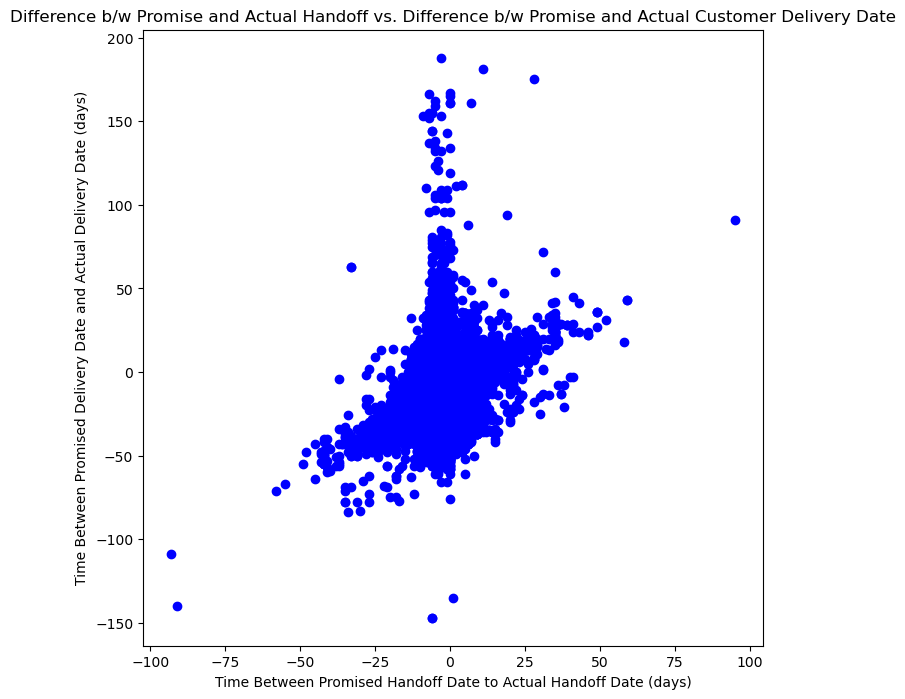

In [30]:
plt.figure(figsize = (8,8))
plt.scatter(x = data[data['promised_handoff_delay']>-150]['promised_handoff_delay'], y = data[data['promised_handoff_delay']>-150]['delivery_delay'],
            color = 'blue', marker = 'o')
plt.ylabel('Time Between Promised Delivery Date and Actual Delivery Date (days)')
plt.xlabel('Time Between Promised Handoff Date to Actual Handoff Date (days)')
plt.title('Difference b/w Promise and Actual Handoff vs. Difference b/w Promise and Actual Customer Delivery Date')
plt.show()

We definitely have multiple factors influencing the results in this case, which is why the correlation is weaker than for just the handoff comparison alone.  This makes sense given that we're not only considering the results of the process by which various sellers get their products to the carriers, but also the processes by which those carriers get the products to customers all over Brazil. We saw in the EDA that there is considerable variance in delivery delay across regions, which is only one factor influencing the results displayed above.  Given the reduction in correlation coefficient, we will next determine how often a delay in handoff literally leads to a late customer delivery.  From the EDA, we know that 7.62% of all customer deliveries in the initial dataset are late, but the fully cleaned dataset used for the research question analyses has >4k less records than the EDA set, so we will re-run the late deliveries analysis and a concurrent analysis to identify late handoffs, then combine the two:

In [32]:
data['delivered_late'] = data['order_delivered_customer_date']>data['order_estimated_delivery_date']
print(data['delivered_late'].value_counts(normalize=True))
print(data['delivered_late'].value_counts())

delivered_late
False    0.934723
True     0.065277
Name: proportion, dtype: float64
delivered_late
False    102169
True       7135
Name: count, dtype: int64


In [34]:
data['handoff_late'] = data['order_delivered_carrier_date']>data['shipping_limit_date']
print(data['handoff_late'].value_counts(normalize=True))
print(data['handoff_late'].value_counts())

handoff_late
False    0.940798
True     0.059202
Name: proportion, dtype: float64
handoff_late
False    102833
True       6471
Name: count, dtype: int64


In [36]:
data['both_late'] = (data['handoff_late'] & data['delivered_late'])

print(data['both_late'].value_counts(normalize=True));
print(data['both_late'].value_counts());

both_late
False    0.98484
True     0.01516
Name: proportion, dtype: float64
both_late
False    107647
True       1657
Name: count, dtype: int64


Even though the proportions of orders where there was a late handoff or a late delivery are within 0.5%, only 1.48% of orders (1657) experienced both, as illustrated below:

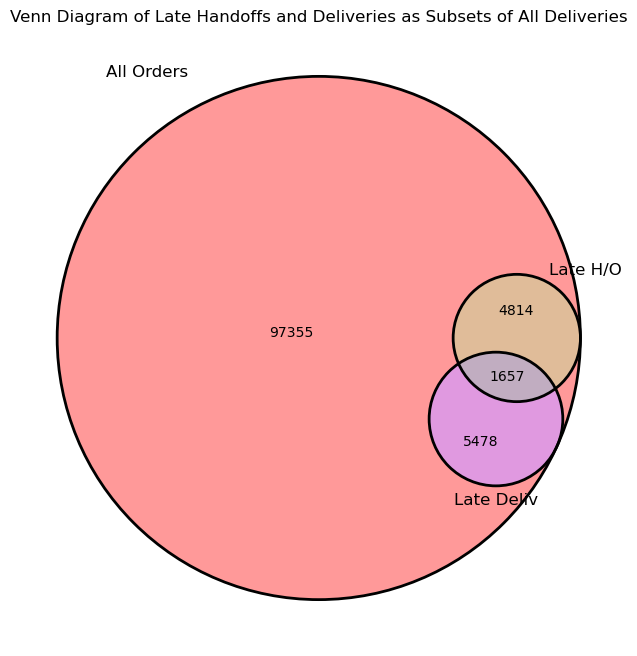

In [38]:
# Create values for conditions to ease calculations
ords = 109304 # All orders
lateh = 6471 # Orders with late handoff
lated = 7135 # Orders with late delivery
both = 1657 # Orders with both late handoff and late delivery

Abc = ords - (lateh + lated - both)
aBc = 0
abC = 0
ABc = lateh - both
aBC = 0
AbC = lated - both
ABC = both

plt.figure(figsize = (8,8))
mv.venn3(subsets = (Abc, aBc, ABc, abC, AbC, aBC, ABC), set_labels = ('All Orders', 'Late H/O', 'Late Deliv'))
mv.venn3_circles(subsets = (Abc, aBc, ABc, abC, AbC, aBC, ABC))
plt.title('Venn Diagram of Late Handoffs and Deliveries as Subsets of All Deliveries')
plt.show()

\*NOTE: in the above Venn diagram, the numbers represent the size of the area that DOES NOT OVERLAP with another, so the 97355 represents deliveries that were neither handed off late nor delivered late.

Before digging any further into the effect (if any) of sellers on late deliveries, ostensibly due to late handoffs, we first must test if the two "lateness" proportions are associated with each other in a statistically significant fashion.  

**Note that this IS A DEVIATION FROM THE ORIGINAL METHODOLOGY, as we realized that the Venn diagram itself was insufficient to determine if the association between the two conditions was statistically significant, and therefore worthy of continued investigation.**

For this analysis we will use a chi-squared test test of association (or independence depending on your perspective) using a contingency table based on the above Venn diagram.

In [40]:
# Create the contingency table via crosstabulation and show that the combinations have the same values as in the Venn diagram
cont_tbl = pd.crosstab(data['handoff_late'], data['delivered_late'], rownames = ['handoff_late'], colnames = ['delivered_late'])
print(cont_tbl)

# Perform chi-squared test based on contingency table
import scipy.stats as sps

# Perform the Chi-square test
# Default null hypothesis is that late handoffs ARE INDEPENDENT of late deliveries
chi2, p, dof, expected = sps.chi2_contingency(cont_tbl)
crit = sps.chi2.ppf(0.975, 1)  # Use 0.025 since for 2-sided test we need 1-a/2

print(f"\nCritical value: {crit:.3f}")
print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.3f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:\n", expected)

delivered_late  False  True 
handoff_late                
False           97355   5478
True             4814   1657

Critical value: 5.024
Chi-square statistic: 4100.040
P-value: 0.000
Degrees of freedom: 1
Expected frequencies:
 [[96120.40526422  6712.59473578]
 [ 6048.59473578   422.40526422]]


__**Since the p-value is <0.05 and the test statistic is larger than 5.024, we reject the null hypothesis and conclude that late handoffs are not independent of late deliveries**__

## Part 2: Which Sellers Hand Off Consistently Late, Which Leads to Late Deliveries? What Patterns or Behaviors Can Be Identified, If Any, That Contribute to That Lateness?

### Identify Sellers with Late Handoffs and Deliveries

In [42]:
# Create sorted list of concurent late handoff and delivery totals by seller
seller_late = pd.DataFrame(data.groupby('seller_id')['both_late'].sum().sort_values(ascending = False))

In [44]:
# Determine number of sellers involved with combination late handoff and late delivery orders
seller_late[seller_late['both_late']>0].count()

both_late    498
dtype: int64

In [46]:
seller_late['both_late'].value_counts()

both_late
0     2418
1      250
2       86
3       38
4       33
5       21
7       14
6       13
10       7
8        6
11       6
9        5
19       3
14       3
12       2
13       2
53       1
15       1
20       1
21       1
26       1
37       1
44       1
45       1
69       1
Name: count, dtype: int64

In [48]:
# Create cumulative % of total column for plotting line chart over bar chart to complete Pareto chart
s_l = seller_late[seller_late['both_late']>5]
s_l.reset_index(drop = False, inplace = True)
s_l.loc[len(s_l)] = ['<6 orders', 428]
s_l['cum_pct'] = (s_l['both_late'].cumsum()/s_l['both_late'].sum())*100

### Plot Pareto Chart

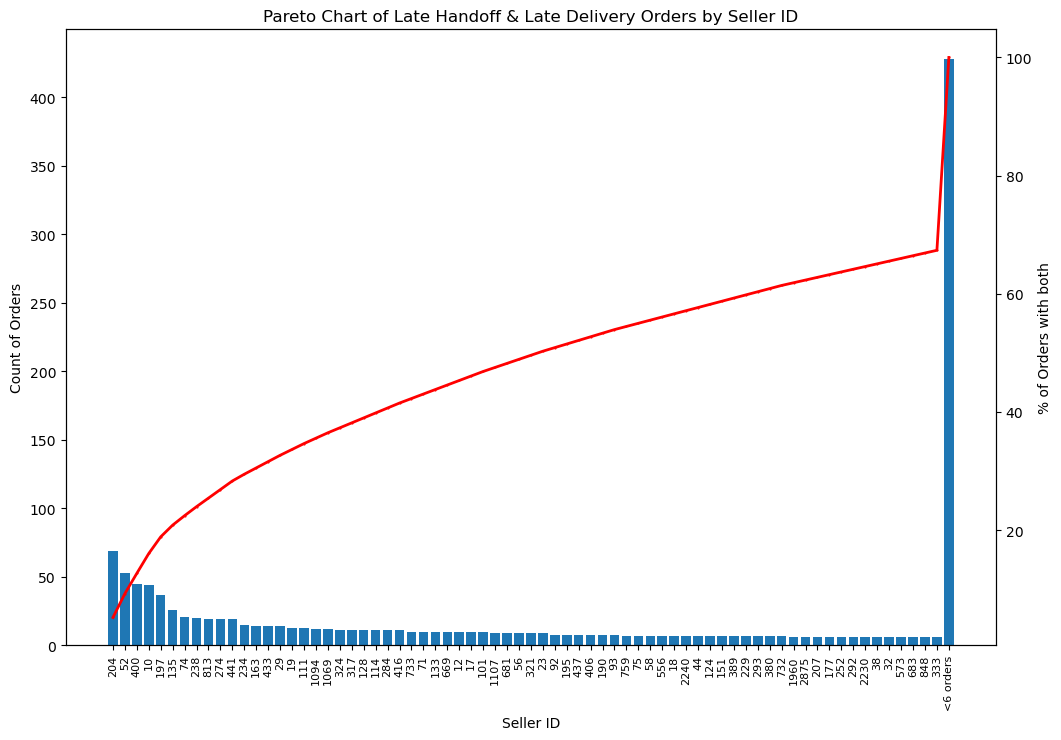

In [50]:
fig, ax = plt.subplots(figsize = (12,8));
xyz = ax.bar(x = range(1,len(s_l['seller_id'])+1), height = s_l['both_late'])
ax.xaxis.set_ticks(ticks = range(1,len(s_l['seller_id'])+1), labels = s_l['seller_id'], fontsize = 8, rotation = 'vertical')
ax.set_xlabel('Seller ID')
ax.set_ylabel('Count of Orders')
ax2 = ax.twinx()
ax2.plot(range(1,len(s_l['seller_id'])+1), s_l['cum_pct'], '.r-', linewidth = 2, markersize = 1)
ax2.set_ylabel('% of Orders with both')
plt.title('Pareto Chart of Late Handoff & Late Delivery Orders by Seller ID')
plt.show();

Clearly, the Pareto Principle (80% or more of the issues are caused by 20% or less of the items/vendors/parts/etc., so focus on the 20% or less) does not apply here, as we would need to include over 100 vendors of the 498 to cover 80% or more of the 1657 late deliveries with late handoffs, in fact, we would need to include almost half of them to do so.

While we have identified the sellers that have the most late handoffs leading to late deliveries by count, we have not addressed the rate of "double lateness", which we address below:

In [52]:
ords_top = pd.DataFrame(data.groupby('seller_id')['order_id'].count())
ords_top.reset_index(inplace=True)
ords_top = ords_top.sort_values(by='order_id', ascending=False).head(50)
late_top = s_l.head(50)

In [54]:
vendors = pd.Series(ords_top[ords_top['seller_id'].isin(s_l['seller_id'])]['seller_id'])

In [56]:
ords = pd.DataFrame(data.groupby('seller_id')['order_id'].count())
ords.reset_index(inplace=True)
ords.rename(columns = {'order_id':'order_count'}, inplace=True)
tot_ords = ords[ords['seller_id'].isin(vendors)]['order_count'].sum()
tot_late = s_l[s_l['seller_id'].isin(vendors)]['both_late'].sum()

print(f"The {len(vendors):d} vendors in both 'Top 50' lists handled {tot_ords:d} orders ({tot_ords/len(data)*100:.1f}% of all orders), with {tot_late:d} or {tot_late/tot_ords*100:.2f}% of those being handed off and delivered late.")

The 24 vendors in both 'Top 50' lists handled 20200 orders (18.5% of all orders), with 394 or 1.95% of those being handed off and delivered late.


The late-for-both rate of 1.95% for these top sellers by order count and late-for-both count is close in value to the 1.52% of all orders that were late-for-both that was calculated above in Part 1 (see the result from above).  While the rate among the top sellers is higher by absolute value, we need that difference to be statistically significant to convince ourselves that the suppliers themselves contribute something significant to the difference, so we will perform a two-sample chi-squared test of equal proportions (a type of hypothesis test) to determine if we can consider the values to not be equal, and therefore that we need to investigate the effect of sellers further:

In [58]:
# establish input values for the test
all_orders = len(data)  # All orders in the database, which was shown above to be 109304
sub_orders = tot_ords   # Subset of orders from the overlap of top sellers and late-for-both sellers, shown in the cell above to be 20200
all_late = 1657         # Number of late-for-both orders in the entire database, from above
sub_late = 394          # Number of late-for-both orders in the subset of interest from the sub_orders set
value = 0               # Stating outright even though it's the default just to be clear that the null hypothesis is that the 2 proportions are equal

# Set up the proportions test using statsmodels function and alpha level of 0.05, meaning the target statistic is z(0.025) = 1.96 for 2-sided test
zstat, pvalue = smsp.proportions_ztest(count = np.array([sub_late, all_late]), nobs = np.array([sub_orders, all_orders]), value = 0,
                                       alternative = 'two-sided', prop_var = False);
print(f"The calculated test statistic is {zstat:.3f} with a p-value of {pvalue:.3f}")

The calculated test statistic is 4.545 with a p-value of 0.000


Since the test statistic was greater than 1.96 with a p-value less than 0.05, we reject the null hypothesis and conclude that the two proportions are not the same to the 0.05 level of uncertainty.  Therefore, we will proceed with the modeling exercise to determine if we can create a predictive model to anticipate late deliveries based on late handoffs.

The first look we take is to determine if the top 10 product categories are the same when both the handoff and delivery were late as those for when just the delivery was late as shown in the EDA

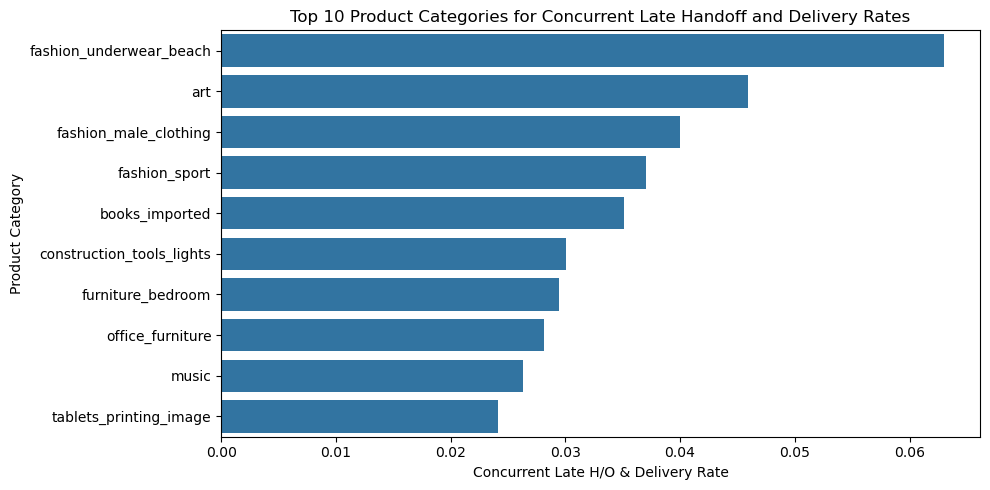

In [60]:
cat_late_both = data.groupby('product_category_name_english')['both_late'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=cat_late_both.values, y=cat_late_both.index)
plt.title('Top 10 Product Categories for Concurrent Late Handoff and Delivery Rates')
plt.xlabel('Concurrent Late H/O & Delivery Rate')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

Only 2 of the categories actually make each list (both above and the one in Section VI.B of the EDA), 'fashion_underwear_beach' and 'construction_tools_lights'.  At this point, instead of attempting to go through each feature individually, we will simply start attempting to model the results and use feature selection algorithms to determine what is the most predictive set.

## Predictive Modeling

In [62]:
# Remove irrelevant columns from data set before modeling begins, and split off target field (both_late) as the y variable
data.drop(columns = ['order_item_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_estimated_delivery_date',
                         'is_canceled','customer_zip_code_prefix', 'customer_city', 'seller_zip_code_prefix','order_delivered_customer_date',
                         'shipping_limit_date', 'order_delivered_carrier_date', 'product_id', 'delivered_late', 'order_id', 'customer_id',
                         'customer_unique_id', 'handoff_late', 'seller_city', 'price', 'freight_value'], inplace = True)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 109304 entries, 0 to 111716
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_state                 109304 non-null  object 
 1   seller_state                   109304 non-null  object 
 2   distance_km                    109304 non-null  float64
 3   product_category_name_english  107757 non-null  object 
 4   product_weight_g               109287 non-null  float64
 5   product_length_cm              109287 non-null  float64
 6   product_height_cm              109287 non-null  float64
 7   product_width_cm               109287 non-null  float64
 8   delivery_delay                 109304 non-null  float64
 9   seller_id                      109304 non-null  int64  
 10  handoff_delay                  109303 non-null  float64
 11  promised_handoff_delay         109303 non-null  float64
 12  both_late                      1093

In [64]:
# Drop NA rows
data = data.dropna()
data.shape

(107756, 13)

In [66]:
# Split predictors and result column, convert boolean to binomial with {0,1} integer values
X = data.drop(columns=['both_late'], inplace = False)
yb = data['both_late']
y = yb.astype(int)
del(yb)  # Drop interim variable

# Encode variables for regression analysis prior to splitting so as not to miss any category values in any field
cat_cols = ['customer_state', 'seller_state', 'product_category_name_english', 'seller_id']
num_cols = ['distance_km', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
            'delivery_delay', 'handoff_delay', 'promised_handoff_delay']
proc = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),('num', StandardScaler(), num_cols)])

# Encode categories and scale numerical columns
X_encode = proc.fit_transform(X)

# Extract encoded set feature names
if hasattr(X_encode, 'toarray'):
    X_encode = X_encode.toarray()

# Get column names from encoded set
cat_names = proc.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_names = list(cat_names) + num_cols

# Reconvert encoded set to dataframe with proper headers then drop original X to free memory
X_new = pd.DataFrame(X_encode, columns = all_names)
del(X)

x_train, x_test, y_train, y_test = train_test_split(X_new, y, test_size = 0.2, random_state = 42, stratify = y)

We used the stratify option/parameter in train_test_split above to enable use of StratifiedKFold cross-validation during tuning and fitting.

In [70]:
# Due to highly imbalanced nature of the target variable, apply SMOTE from the 'imbalanced' sklearn (imblearn) package to oversample the minority
# class (in our case, when both delivery and handoff late = TRUE) and prevent majority bias in the regression

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [72]:
x_train_smote.shape

(169828, 2988)

### Logistic Regression

In [74]:
# Initialize scikit-learn objects to execute feature selection optimization
scv = StratifiedKFold(shuffle = True, random_state = 42)
model = LogisticRegression(max_iter = 500, solver = 'lbfgs', verbose = 0, random_state = 42)

#### Feature Reduction

In [76]:
# Perform feature reduction

feats = []
scores = []
# Hyperparameter tuning for # of features
for i in range(49,0,-2):
    print(f"Running recursion for {i} features")
    selector = RFE(
        estimator = model,
        step = 0.1,
        n_features_to_select = i,
        verbose = 0)
    selector.set_output(transform="pandas")
    selector.fit(x_train_smote, y_train_smote)
    pred = selector.predict(x_test)
    feats.append(i)
    scores.append(fbeta_score(y_test, pred, beta = 2, pos_label = 1, average = 'binary'))


Running recursion for 49 features
Running recursion for 47 features
Running recursion for 45 features
Running recursion for 43 features
Running recursion for 41 features
Running recursion for 39 features
Running recursion for 37 features
Running recursion for 35 features
Running recursion for 33 features
Running recursion for 31 features
Running recursion for 29 features
Running recursion for 27 features
Running recursion for 25 features
Running recursion for 23 features
Running recursion for 21 features
Running recursion for 19 features
Running recursion for 17 features
Running recursion for 15 features
Running recursion for 13 features
Running recursion for 11 features
Running recursion for 9 features
Running recursion for 7 features
Running recursion for 5 features
Running recursion for 3 features
Running recursion for 1 features


#### Plot Reduction Optimization Results

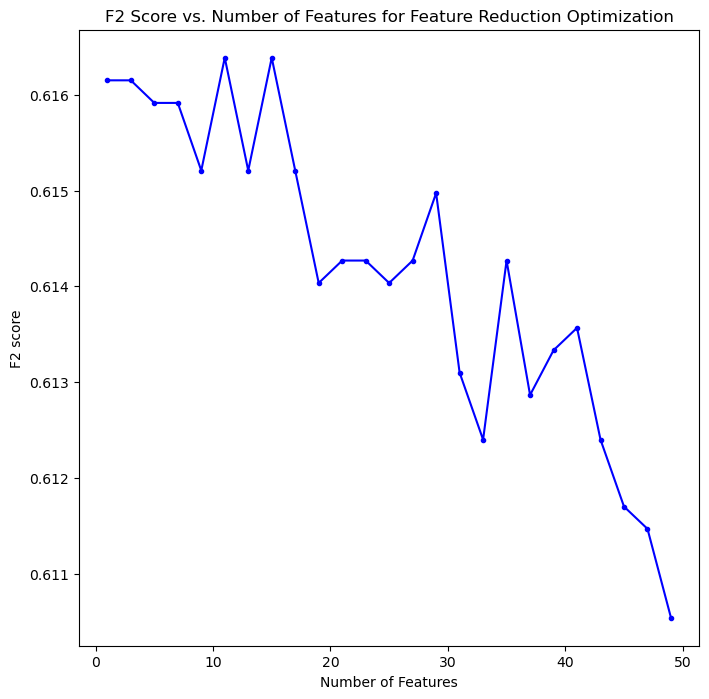

In [78]:
# Plot test set score vs. # of features
plt.figure(figsize = (8,8))
plt.plot(feats, scores, '.-b')
plt.xlabel('Number of Features')
plt.ylabel('F2 score')
plt.title('F2 Score vs. Number of Features for Feature Reduction Optimization')
plt.show()

#### Apply fit to limit features in training and test set

In [80]:
i = 12
selector1 = RFE(
        estimator = model,
        step = 0.1,
        n_features_to_select = i,
        verbose = 0)
selector1.set_output(transform = "pandas")
x_train_xform = selector1.fit_transform(x_train_smote, y_train_smote)
x_test_xform = selector1.transform(x_test)

# Create DataFrame to carry column names for model fitting
names = selector1.get_feature_names_out()
x_train_xform1 = pd.DataFrame(x_train_xform, columns = names)

#### Use Statsmodels for model fit to enable regression reporting and odds calculations - duplicate model above using 'lbfgs' solver in both

In [87]:
from statsmodels.discrete.discrete_model import Logit

logit = Logit(y_train_smote, sm.add_constant(x_train_xform1))
fit = logit.fit(method = 'lbfgs', maxiter=500)
print(fit.summary())

                           Logit Regression Results                           
Dep. Variable:              both_late   No. Observations:               169828
Model:                          Logit   Df Residuals:                   169815
Method:                           MLE   Df Model:                           12
Date:                Wed, 18 Jun 2025   Pseudo R-squ.:                  0.7889
Time:                        06:57:27   Log-Likelihood:                -24854.
converged:                       True   LL-Null:                   -1.1772e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                                             -5.2331      0.037   -142.545      0.000      -5.305      -5.161
product_category_name_e

All coefficients were found to be statistically significant, so we will not have to alter the training or test sets further.

#### Perform threshold optimization for test results

In [98]:
# Create prediction probabilities for test set to use for threshold hyperparameter tuning
pred =  fit.predict(sm.add_constant(x_test_xform))

f2=[]
th = np.arange(1,0.5,-0.02)
# Create F2 and threshold pairs for plotting
for j in range(0,len(th),1):
    y_pred = (pred>=th[j]).astype(int)
    f2.append(fbeta_score(y_test, y_pred, beta = 2, pos_label = 1, average = 'binary'))

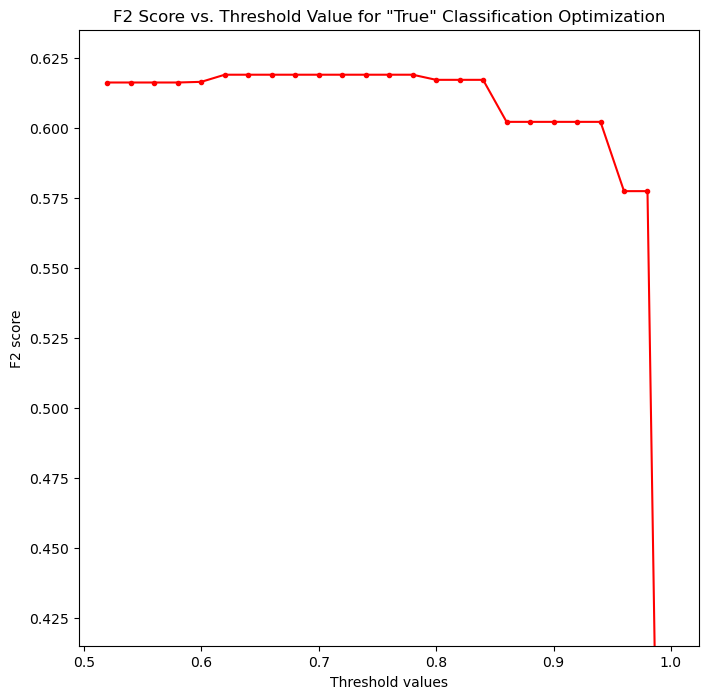

In [100]:
# Plot F2 score vs. threshold values
plt.figure(figsize = (8,8))
plt.plot(th, f2, '.-r')
plt.xlabel('Threshold values')
plt.ylabel('F2 score')
plt.title('F2 Score vs. Threshold Value for "True" Classification Optimization')
plt.ylim(0.415, 0.635)
plt.show()

In [102]:
th[f2==max(f2)]

array([0.78, 0.76, 0.74, 0.72, 0.7 , 0.68, 0.66, 0.64, 0.62])

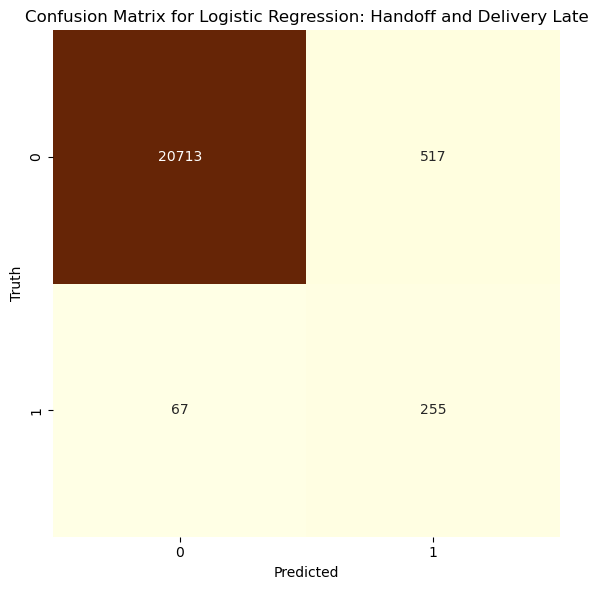

In [104]:
# Apply best threshold value
y_pred = (pred>0.62).astype(int)

# Display confusion matrix and recall score for optimium model with threshold value of 0.789 applied to results
plt.figure(figsize = [8,6])
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd', cmap = 'YlOrBr', cbar = False, square = True)
plt.title('Confusion Matrix for Logistic Regression: Handoff and Delivery Late')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.tight_layout()
plt.show()

In [106]:
print(f"Recall score = {recall_score(y_test, y_pred, pos_label = 1, average = 'binary'):.3f}")
print(f"Overall accuracy = {accuracy_score(y_test, y_pred):.3f}")

Recall score = 0.792
Overall accuracy = 0.973


#### Generate and show odds ratios for each model feature

In [122]:
summary = fit.summary()
odds = pd.read_html(summary.tables[1].as_html(), header = 0, index_col = 0)[0]
odds['odds'] = np.exp(odds['coef'])
odds_table = odds.filter(['coef', 'odds', 'P>|z|'], axis = 1)
print(odds_table)

                                                  coef         odds  P>|z|
const                                          -5.2331     0.005337  0.000
product_category_name_english_air_conditioning -7.4844     0.000562  0.000
seller_id_121                                   0.9069     2.476633  0.002
seller_id_238                                   1.2568     3.514158  0.000
seller_id_270                                   1.7143     5.552787  0.000
seller_id_546                                   2.1255     8.377085  0.000
seller_id_818                                   3.7924    44.362743  0.000
seller_id_885                                   1.3241     3.758801  0.000
seller_id_1838                                  2.9486    19.079224  0.000
seller_id_1925                                  4.2337    68.971957  0.000
seller_id_2230                                  5.9673   390.450031  0.000
seller_id_2875                                  2.0495     7.764018  0.025
promised_handoff_delay   

### Support Vector Machine

Thankfully, we can use the same encoding scheme for the SVM as for the regression.  As discussed in the methodology, we are using Linear Support Vector Classification (LinearSVC) for our model because it scales to large sample sizes better than the other support vector machine models.

In [126]:
# Perform feature reduction
model2 = LinearSVC(loss = 'hinge', C = 0.001, verbose = 0, random_state = 42, max_iter = 500)

feats2 = []
scores2 = []

# Hyperparameter tuning for # of features
for i in range(49,0,-2):
    print(f"Running recursion for {i} features")
    selector2 = RFE(
        estimator = model2,
        step = 0.1,
        n_features_to_select = i,
        verbose = 0)
    selector2.set_output(transform="pandas")
    selector2.fit(x_train_smote, y_train_smote)
    pred2 = selector2.predict(x_test)
    feats2.append(i)
    scores2.append(fbeta_score(y_test, pred2, beta = 2, pos_label = 1, average = 'binary'))

Running recursion for 49 features
Running recursion for 47 features
Running recursion for 45 features
Running recursion for 43 features
Running recursion for 41 features
Running recursion for 39 features
Running recursion for 37 features
Running recursion for 35 features
Running recursion for 33 features
Running recursion for 31 features
Running recursion for 29 features
Running recursion for 27 features
Running recursion for 25 features
Running recursion for 23 features
Running recursion for 21 features
Running recursion for 19 features
Running recursion for 17 features
Running recursion for 15 features
Running recursion for 13 features
Running recursion for 11 features
Running recursion for 9 features
Running recursion for 7 features
Running recursion for 5 features
Running recursion for 3 features
Running recursion for 1 features


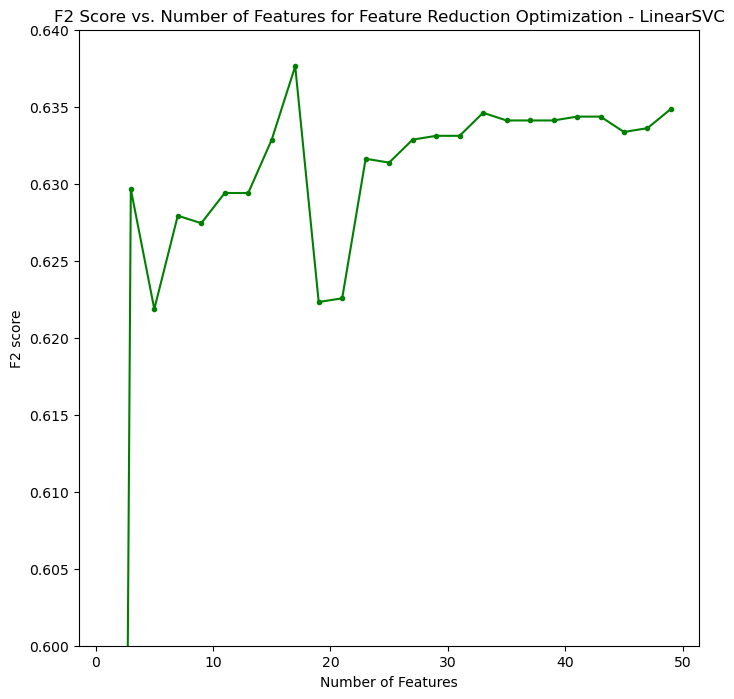

In [132]:
# Plot test set score vs. # of features
plt.figure(figsize = (8,8))
plt.plot(feats2, scores2, '.-g')
plt.xlabel('Number of Features')
plt.ylabel('F2 score')
plt.title('F2 Score vs. Number of Features for Feature Reduction Optimization - LinearSVC')
plt.ylim(0.6, 0.64)
plt.show()

In [134]:
# Apply best set of features
i = 18
selector2 = RFE(
    estimator = model2,
    step = 0.1,
    n_features_to_select = i,
    verbose = 0)
x_train_xform2 = selector2.fit_transform(x_train_smote, y_train_smote)

In [136]:
names2 = selector2.get_feature_names_out()
print(names2)

['customer_state_ba' 'customer_state_ce' 'customer_state_pr'
 'customer_state_rj' 'customer_state_sc' 'customer_state_sp'
 'seller_state_mg' 'seller_state_pr' 'seller_state_rj' 'seller_state_sc'
 'seller_state_sp' 'product_category_name_english_bed_bath_table'
 'product_category_name_english_sports_leisure' 'seller_id_8'
 'seller_id_250' 'delivery_delay' 'handoff_delay' 'promised_handoff_delay']


In [140]:
# Hyperparameter tuning - since the L1 penalty is not supported in combination with standard hinge loss, we will not use the L1 penalty type

params2 = {'C':[0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'loss': ['hinge', 'squared_hinge']}
scorer = make_scorer(fbeta_score, beta = 2)

# Initialize optimization routine
tuner2 = GridSearchCV(
    estimator = model2,
    param_grid = params2,
    scoring = scorer,
    cv = scv,
    verbose = 2)

# Execute fitting
tuner2.fit(x_train_smote, y_train_smote)

# Pull best fit
best_model2 = tuner2.best_estimator_
print("The model with the best score used these parameters: ", tuner2.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ...............................C=0.0001, loss=hinge; total time=  12.7s
[CV] END ...............................C=0.0001, loss=hinge; total time=  12.8s
[CV] END ...............................C=0.0001, loss=hinge; total time=  13.0s
[CV] END ...............................C=0.0001, loss=hinge; total time=  12.6s
[CV] END ...............................C=0.0001, loss=hinge; total time=  12.7s
[CV] END .......................C=0.0001, loss=squared_hinge; total time=  12.9s
[CV] END .......................C=0.0001, loss=squared_hinge; total time=  12.2s
[CV] END .......................C=0.0001, loss=squared_hinge; total time=  12.8s
[CV] END .......................C=0.0001, loss=squared_hinge; total time=  12.3s
[CV] END .......................C=0.0001, loss=squared_hinge; total time=  12.6s
[CV] END ................................C=0.001, loss=hinge; total time=  12.7s
[CV] END ................................C=0.001

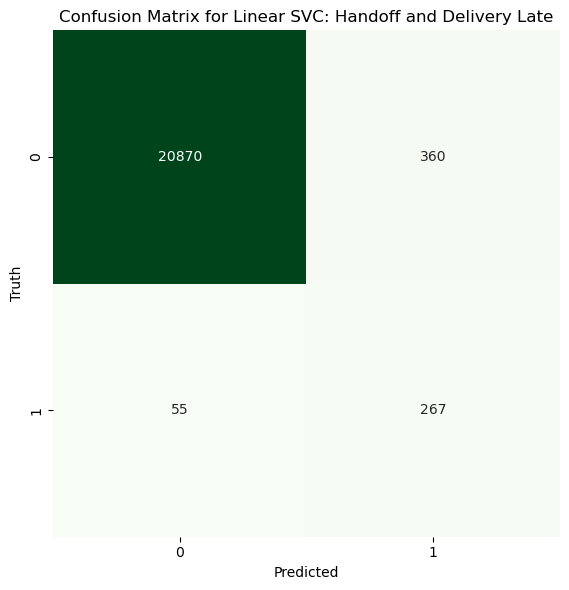

In [144]:
# Create prediction probabilities for test set to use for threshold hyperparameter tuning
pred2 = best_model2.predict(x_test)

plt.figure(figsize = [8,6])
sns.heatmap(confusion_matrix(y_test, pred2), annot = True, fmt = 'd', cmap = 'Greens', cbar = False, square = True)
plt.title('Confusion Matrix for Linear SVC: Handoff and Delivery Late')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.tight_layout()
plt.show()

In [146]:
print(f"Recall score = {recall_score(y_test, pred2, pos_label = 1, average = 'binary'):.3f}")
print(f"Overall accuracy = {accuracy_score(y_test, pred2):.3f}")

Recall score = 0.829
Overall accuracy = 0.981
